In [1]:
from matplotlib import pyplot as plt
import matplotlib as mpl
import numpy as np
import scipy.io as sio
import pandas as pd


In [2]:
home_dir = "/Users/smb-uh/UHM_Ocean_BGC_Group Dropbox/Seth Bushinsky/"
manuscript_dir = home_dir + "Work/Manuscripts/2019_06 SO CMIP Comparison/"

plot_ver = '_v17' # this should be saved in the variable files, can check for it later

In [3]:
df = pd.read_csv(manuscript_dir + 'spreadsheets/Table_S1_v17.csv',  index_col=[0])
df

,fgco2_correlation,fgco2_ratio,fgco2_norm_error,spco2_correlation,spco2_ratio,spco2_norm_error,dissic_correlation,dissic_ratio,dissic_norm_error,tos_correlation,...,sos_norm_error,talk_correlation,talk_ratio,talk_norm_error,mld_correlation,mld_ratio,mld_norm_error,intpp_correlation,intpp_ratio,intpp_norm_error
Model_Name,,,,,,,,,,,,,,,,,,,,,
CESM1_BGC,0.944810,0.989128,0.330603,0.959115,0.670002,0.404581,0.966307,1.101481,0.290727,0.999344,...,0.935216,0.981040,0.695064,0.345459,0.988753,0.688285,0.335632,0.863300,2.076881,1.314341
CMCC_CESM,-0.472446,1.776609,2.415583,-0.541379,1.774212,2.463508,0.872650,0.926841,0.491344,0.998637,...,1.506144,0.933768,1.139197,0.412648,0.972390,0.519030,0.509895,0.459310,1.617503,1.459604
CNRM_CM5,-0.836466,0.820512,1.745251,NaN,NaN,NaN,0.826853,0.700622,0.576410,0.994216,...,0.353374,0.852813,0.353293,0.722655,0.996802,0.578991,0.425384,0.633760,1.123990,0.915791
CanESM2,-0.763573,4.676092,5.477857,-0.801702,0.852538,1.758916,0.798618,0.835364,0.602959,0.994493,...,0.334032,0.952635,0.424210,0.609688,0.997428,0.646151,0.358515,0.881650,0.703086,0.504558
GFDL_ESM2G,-0.807751,0.518032,1.450945,-0.886444,0.654953,1.609386,0.898851,0.828995,0.443787,0.997891,...,0.187582,0.855111,0.206156,0.830619,0.982287,0.800474,0.261089,0.881093,2.414854,1.605022
GFDL_ESM2M,-0.564347,0.618620,1.442540,-0.677562,0.716811,1.576447,0.915086,1.046671,0.424185,0.996732,...,0.397551,0.708150,0.229442,0.853045,0.987915,0.679817,0.344889,0.833281,2.478507,1.735630
GISS_E2_H_CC,0.658183,1.149037,0.898740,0.693784,1.565013,1.130356,0.968771,2.005525,1.065993,0.987954,...,2.522922,NaN,NaN,NaN,0.948986,0.962116,0.315592,0.869044,1.091870,0.542599
GISS_E2_R_CC,0.333765,1.139179,1.239876,0.499566,1.129279,1.070968,0.885981,1.334994,0.645484,0.994936,...,0.439535,NaN,NaN,NaN,0.960961,1.594614,0.691427,0.878086,1.468171,0.759715
HadGEM2_CC,0.766652,1.161202,0.753602,0.801621,1.882863,1.235512,0.983422,1.282139,0.349446,0.991575,...,0.607867,0.689946,0.612912,0.727948,0.988131,0.790576,0.250250,0.892884,4.404282,3.540151


In [94]:
for key in df.keys():
    print(key)
    print(str(round(max(df[key]),2)) + ' ' + str(round(min(df[key]),2)), end='')
    print(' ')

fgco2_correlation
0.94 -0.98 
fgco2_ratio
6.29 0.25 
fgco2_norm_error
7.21 0.33 
spco2_correlation
0.96 -0.99 
spco2_ratio
3.51 0.3 
spco2_norm_error
2.89 0.4 
dissic_correlation
0.99 0.75 
dissic_ratio
2.01 0.32 
dissic_norm_error
1.07 0.24 
tos_correlation
1.0 0.99 
tos_ratio
2.58 0.83 
tos_norm_error
1.59 0.04 
sos_correlation
1.0 0.85 
sos_ratio
3.42 0.55 
sos_norm_error
2.52 0.13 
talk_correlation
0.98 -0.74 
talk_ratio
1.14 0.2 
talk_norm_error
1.46 0.21 
mld_correlation
1.0 0.92 
mld_ratio
1.59 0.44 
mld_norm_error
0.69 0.17 
intpp_correlation
0.92 0.33 
intpp_ratio
5.82 0.31 
intpp_norm_error
5.27 0.42 


In [39]:
column_names = df.keys()

df_max_min = np.zeros((2,len(column_names)))
for cn in range(0, len(column_names)):
    if 'ratio' in column_names[cn]:
        df_max_min[0,cn] = max(abs(df[column_names[cn]].values-1))
        df_max_min[1,cn] = min(abs(df[column_names[cn]].values-1))
    else:
        df_max_min[0,cn] = max(df[column_names[cn]].values)
        df_max_min[1,cn] = min(df[column_names[cn]].values)
df_max_min

array([[ 9.44809836e-01,  5.28532990e+00,  7.21092667e+00,
         9.59114702e-01,  2.50511793e+00,  2.89350319e+00,
         9.86210716e-01,  1.00552479e+00,  1.07167002e+00,
         9.99343810e-01,  1.58122821e+00,  1.58796732e+00,
         9.96628874e-01,  2.41602517e+00,  2.52292235e+00,
         9.84409803e-01,  8.01613163e-01,  1.46430490e+00,
         9.98521427e-01,  5.94614291e-01,  6.91427285e-01,
         9.20044984e-01,  4.81799237e+00,  5.27127317e+00],
       [-9.80049004e-01,  9.10430335e-03,  3.30603162e-01,
        -9.87862698e-01,  2.07998964e-03,  4.04580559e-01,
         7.47389998e-01,  1.54792485e-02,  2.41135608e-01,
         9.86296429e-01,  3.25820476e-03,  4.18372963e-02,
         8.49505203e-01,  3.08131715e-03,  1.33459391e-01,
        -7.35558931e-01,  5.23072343e-02,  2.05760878e-01,
         9.19296671e-01,  3.78840831e-02,  1.67068775e-01,
         3.33640470e-01,  3.57079007e-02,  4.20458268e-01]])

In [29]:
abs(df[column_names[1]].values-1)

array([0.01087225, 0.77660917, 0.17948778, 3.67609201, 0.48196759,
       0.38138048, 0.14903696, 0.13917918, 0.16120217, 0.057657  ,
       0.44515198, 0.58756188, 0.40553364, 0.21533478, 0.14338016,
       1.59261184, 2.1030912 , 5.2853299 , 0.96832288, 0.0091043 ,
       0.13492771, 0.42532736, 0.3759762 , 0.56193803, 0.15666299,
       0.02817367, 0.16815032, 0.05943051, 0.40209886, 0.15302748,
       0.41121747, 0.30533468, 0.27394132, 0.41623254, 0.34760513,
       0.88525051, 0.02591714, 0.4882052 , 0.71700793, 0.75060301,
       0.75088944, 0.64125422, 0.74320482, 0.28611031])

In [21]:
abs(df_max_min[0,cn]-1)

5.28532990264111

In [22]:
abs(df_max_min[1,cn]-1)

0.750889438382558

0.249110561617442

In [38]:
cn=16
print(column_names[cn])
print(df_max_min[1,cn])
print(df_max_min[0,cn])
range_val = df_max_min[0,cn] - df_max_min[1,cn]

# rgba_color = cmap(norm(.9),bytes=True) 
# print(rgba_color[0]/255)
# print(rgba_color[1]/255)
# print(rgba_color[2]/255)

print(range_val)

print(df[column_names[cn]].values)

talk_ratio
0.05230723426949002
0.1391965010554701
0.08688926678598008
[0.69506412 1.1391965  0.35329334 0.4242101  0.20615612 0.22944167
        nan        nan 0.61291187 0.56262971 0.44542711 0.40786161
 0.68490945        nan        nan 0.58582573 0.56210659 0.94437229
 1.06083128 0.94769277 0.19838684 0.61666987 0.60086628 0.2592445
 0.46618488 0.5014805  0.39351861 0.42940981        nan 0.48731954
 0.27731563        nan        nan 1.09926242 0.30566134 0.41373885
 0.50130835 0.67959841 0.29395011 0.26304729 0.49262789 0.62852615
 0.24545505 0.34840409]


In [40]:
# Don't need to recreate every part of the table, just the main numbers, putting the proper cell colors in pace. 
cmap = mpl.colormaps["PuOr"]
cmap_flipped = mpl.colormaps["PuOr_r"]


# norm_corr = mpl.colors.Normalize(vmin=-0.6, vmax=1.6)  # want 0 to be the best here. 1x below 0, 3x above. 
# norm_ratio = mpl.colors.Normalize(vmin=-3, vmax=9)
# norm_error = mpl.colors.Normalize(vmin=-3.5, vmax=10.5)


column_names = df.keys()
num_models = df.shape[0]

for m in range(0, num_models):
    mod_name = df.index[m]
    mod_values = df.loc[mod_name,:].values
    mod_name_updated = mod_name.replace('_','-')
    no_data = 0
    print('\\textbf{' + mod_name_updated + '} ', end='')
    for idx, val in enumerate(mod_values):
        print('& ', end='')
        if np.isnan(val):
            print( '-' , end='')
        else:

            if  'correlation' in column_names[idx]:
                range_val = df_max_min[0,idx] - df_max_min[1,idx]

                norm_corr = mpl.colors.Normalize(vmin=df_max_min[1,idx] - range_val*.3, vmax=df_max_min[0,idx]+range_val*.3)
                rgba_color = cmap(norm_corr(val),bytes=True) 
            elif 'ratio' in column_names[idx]:
                # rgba_color = [0,0,0]

                # # for ratio, we want better to be closer to 1. 
                val_color = abs(val - 1)
                range_val = df_max_min[0,idx] - df_max_min[1,idx]

                norm_corr = mpl.colors.Normalize(vmin=df_max_min[1,idx] - range_val*.3, vmax=df_max_min[0,idx]+range_val*.3)
                rgba_color = cmap_flipped(norm_corr(val_color),bytes=True) 
            elif 'error' in column_names[idx]:
                range_val = df_max_min[0,idx] - df_max_min[1,idx]

                norm_corr = mpl.colors.Normalize(vmin=df_max_min[1,idx] - range_val*.3, vmax=df_max_min[0,idx]+range_val*.3)
                rgba_color = cmap_flipped(norm_corr(val),bytes=True) 

                # rgba_color = cmap_flipped(norm_error(val),bytes=True) # error is flipped, so closer to 0 is better
            else:
                rgba_color = [0,0,0]
                
            r = rgba_color[0]/255
            g = rgba_color[1]/255
            b = rgba_color[2]/255
            print('\cellcolor[rgb]{' + str(r.round(3)) + ',' + str(g.round(3)) + ','  + str(b.round(3)) + '}' + str(val.round(1)) + ' ', end='')
    print('\\\\', end='')

    print('')



\textbf{CESM1-BGC} & \cellcolor[rgb]{0.475,0.404,0.651}0.9 & \cellcolor[rgb]{0.478,0.416,0.655}1.0 & \cellcolor[rgb]{0.478,0.416,0.655}0.3 & \cellcolor[rgb]{0.478,0.416,0.655}1.0 & \cellcolor[rgb]{0.631,0.596,0.773}0.7 & \cellcolor[rgb]{0.478,0.416,0.655}0.4 & \cellcolor[rgb]{0.576,0.533,0.729}1.0 & \cellcolor[rgb]{0.576,0.533,0.729}1.1 & \cellcolor[rgb]{0.545,0.502,0.706}0.3 & \cellcolor[rgb]{0.475,0.404,0.651}1.0 & \cellcolor[rgb]{0.776,0.765,0.875}1.4 & \cellcolor[rgb]{0.765,0.753,0.867}0.4 & \cellcolor[rgb]{0.624,0.588,0.765}1.0 & \cellcolor[rgb]{0.863,0.871,0.925}1.9 & \cellcolor[rgb]{0.839,0.847,0.918}0.9 & \cellcolor[rgb]{0.478,0.416,0.655}1.0 & \cellcolor[rgb]{0.839,0.847,0.918}0.7 & \cellcolor[rgb]{0.608,0.569,0.753}0.3 & \cellcolor[rgb]{0.624,0.588,0.765}1.0 & \cellcolor[rgb]{0.961,0.961,0.965}0.7 & \cellcolor[rgb]{0.827,0.831,0.91}0.3 & \cellcolor[rgb]{0.592,0.553,0.741}0.9 & \cellcolor[rgb]{0.729,0.71,0.843}2.1 & \cellcolor[rgb]{0.698,0.671,0.824}1.3 \\
\textbf{CMCC-CESM} &

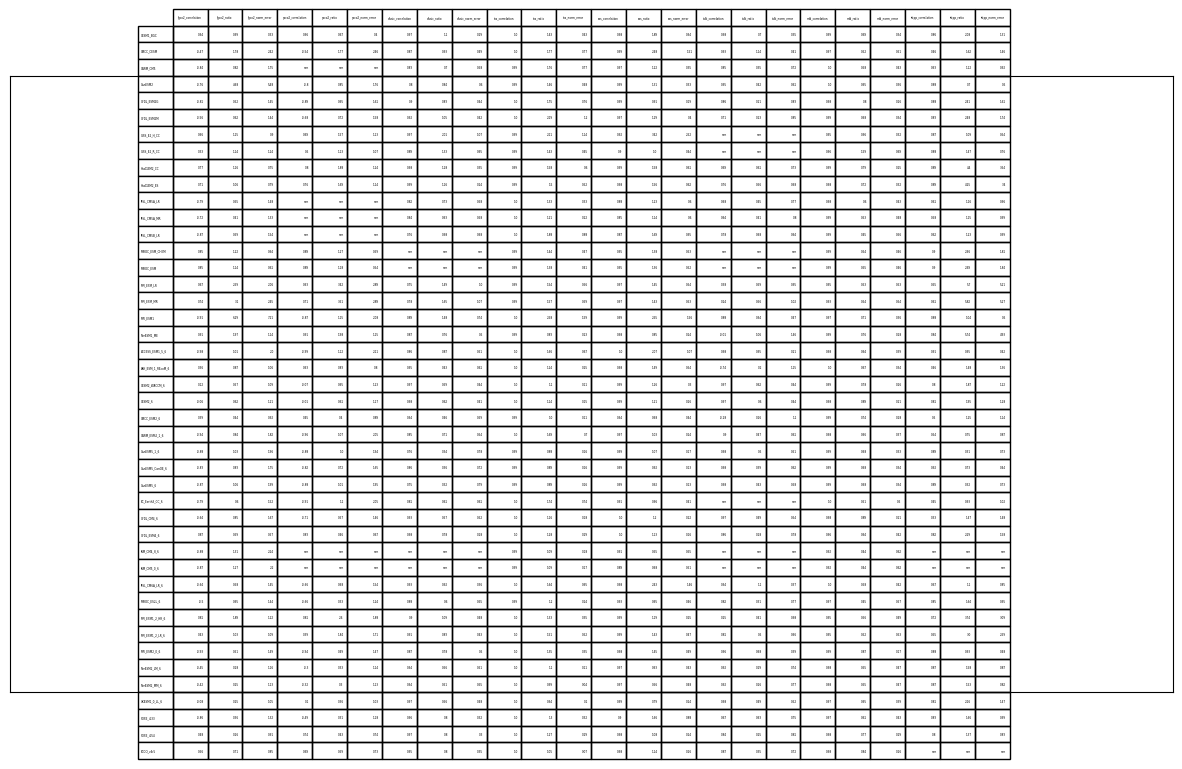

In [23]:
vals = np.around(df.values,2)
norm = plt.Normalize(vals.min()-1, vals.max()+1)
colours = plt.cm.hot(norm(vals))

fig = plt.figure(figsize=(15,8))
ax = fig.add_subplot(111, frameon=True, xticks=[], yticks=[])

the_table=plt.table(cellText=vals, rowLabels=df.index, colLabels=df.columns, 
                    colWidths = [0.03]*vals.shape[1], loc='center', 
                    cellColours=colours)
plt.show()
